Calculated Slope (m): -0.1566
Question 4 - Estimated Crop Field Angle (OLS): 8.90 degrees


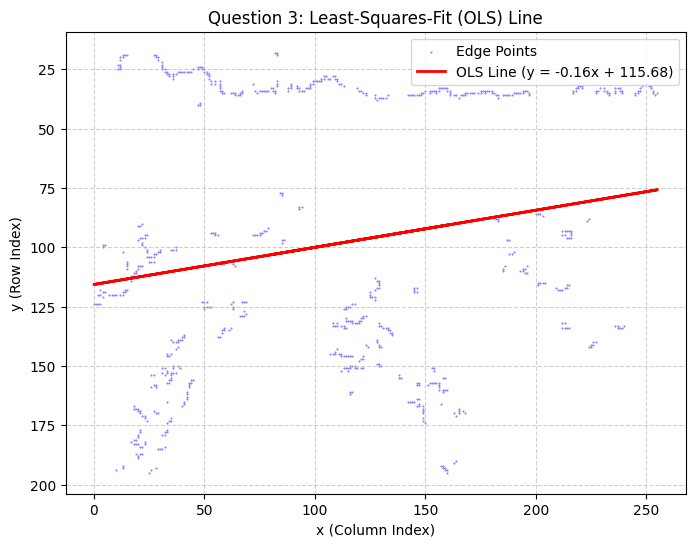

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load the image and get x, y back into memory ---
filename = 'Image of the crop field.png'
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not find '{filename}'.")
else:
    # Extract the coordinates
    edges = cv.Canny(img, 550, 690)
    indices = np.where(edges != 0)
    x = indices[1]
    y = indices[0]

    # --- 3. Ordinary Least Squares (OLS) Fit ---
    # np.polyfit automatically calculates the Least Squares line
    ols_coeffs = np.polyfit(x, y, 1)

    m_ols = ols_coeffs[0] # The slope (m)
    c_ols = ols_coeffs[1] # The intercept (c)

    # Calculate the predicted y-values to draw the line
    y_ols = m_ols * x + c_ols

    # Calculate the angle of the line in degrees (for Question 4)
    angle_ols = np.degrees(np.arctan(m_ols))

    print(f"Calculated Slope (m): {m_ols:.4f}")
    print(f"Question 4 - Estimated Crop Field Angle (OLS): {abs(angle_ols):.2f} degrees")

    # --- Plotting the OLS Line ---
    plt.figure(figsize=(8, 6))

    # Plot the original scatter points 
    plt.scatter(x, y, s=1, c='blue', marker='.', alpha=0.5, label='Edge Points')

    # Plot the red Least Squares line on top
    plt.plot(x, y_ols, color='red', linewidth=2, label=f'OLS Line (y = {m_ols:.2f}x + {c_ols:.2f})')

    plt.gca().invert_yaxis() # Invert Y-axis for image coordinates

    plt.title('Question 3: Least-Squares-Fit (OLS) Line')
    plt.xlabel('x (Column Index)')
    plt.ylabel('y (Row Index)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.show()